In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

Data cleaning and preprocessing

In [119]:
df = pd.read_csv('Bank_Personal_Loan_Modelling(1).csv')

df = df.drop(['ID', 'ZIP Code'], axis=1)
X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


- create preprocessing pipeline
stardadize age, experience, income and CCAvg, family
place actual values for education and one encode that
pass through all the binary variables

In [120]:
df['Education'] = df['Education'].map({
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Professional'
})

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,Undergrad,0,0,1,0,0,0
1,45,19,34,3,1.5,Undergrad,0,0,1,0,0,0
2,39,15,11,1,1.0,Undergrad,0,0,0,0,0,0
3,35,9,100,1,2.7,Graduate,0,0,0,0,0,0
4,35,8,45,4,1.0,Graduate,0,0,0,0,0,1


MISSING VALUES CHECK:
Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64
------------------------------

TARGET VARIABLE IMBALANCE (Personal Loan):
Personal Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


C:\Users\maudt\AppData\Local\Temp\ipykernel_13888\771117587.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Personal Loan', palette='Set1', edgecolor='black')


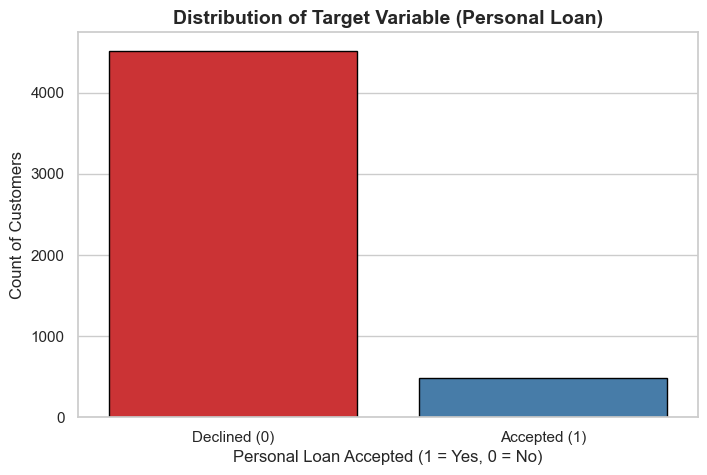

In [121]:
print("MISSING VALUES CHECK:")
print(df.isnull().sum())
print("-" * 30)

print("\nTARGET VARIABLE IMBALANCE (Personal Loan):")
print(df['Personal Loan'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Personal Loan', palette='Set1', edgecolor='black')
plt.title('Distribution of Target Variable (Personal Loan)', fontsize=14, fontweight='bold')
plt.xlabel('Personal Loan Accepted (1 = Yes, 0 = No)')
plt.ylabel('Count of Customers')
plt.xticks(ticks=[0, 1], labels=['Declined (0)', 'Accepted (1)'])
plt.show()

In [122]:
df['Education'] = df['Education'].map({
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Professional'
})

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,NaN,0,0,1,0,0,0
1,45,19,34,3,1.5,NaN,0,0,1,0,0,0
2,39,15,11,1,1.0,NaN,0,0,0,0,0,0
3,35,9,100,1,2.7,NaN,0,0,0,0,0,0
4,35,8,45,4,1.0,NaN,0,0,0,0,0,1


The target variable is imbalanced (~90% class 0, ~10% class 1). We opted not to apply resampling (e.g., SMOTE) because F1 score is used as our evaluation metric, which accounts for this imbalance, and model performance is strong without it

Data distribution Annual income by loan status

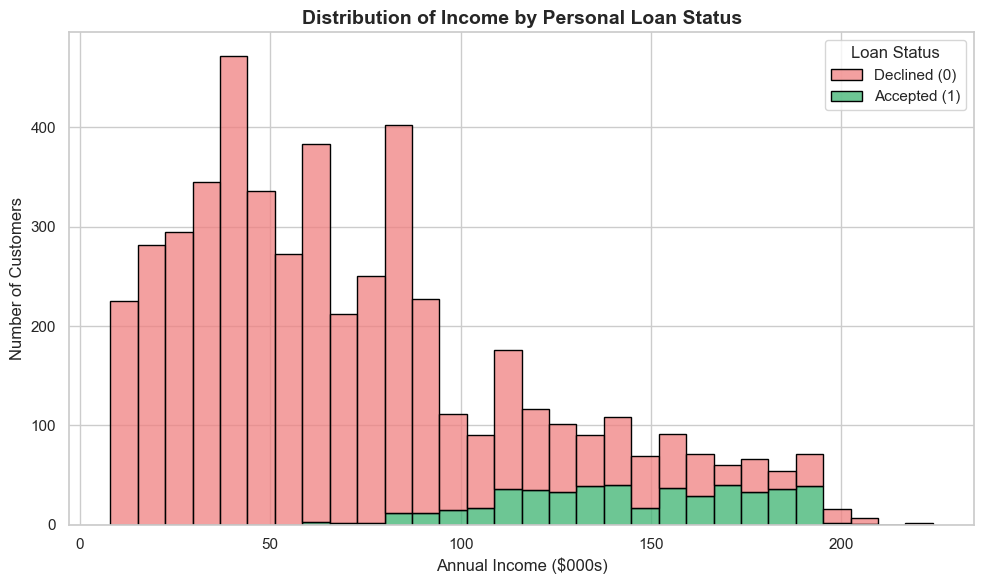

In [123]:
df['Loan Status'] = df['Personal Loan'].map({0: 'Declined (0)', 1: 'Accepted (1)'})

sns.set_theme(style="whitegrid")


custom_colors = {'Declined (0)': 'lightcoral', 'Accepted (1)': 'mediumseagreen'}


plt.figure(figsize=(10, 6))
sns.histplot(
    data=df, 
    x='Income', 
    hue='Loan Status', 
    multiple="stack", 
    bins=30, 
    palette=custom_colors,
    edgecolor='black'
)
plt.title('Distribution of Income by Personal Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($000s)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()


Data distribution credit card spending(CCAvg) by loan status

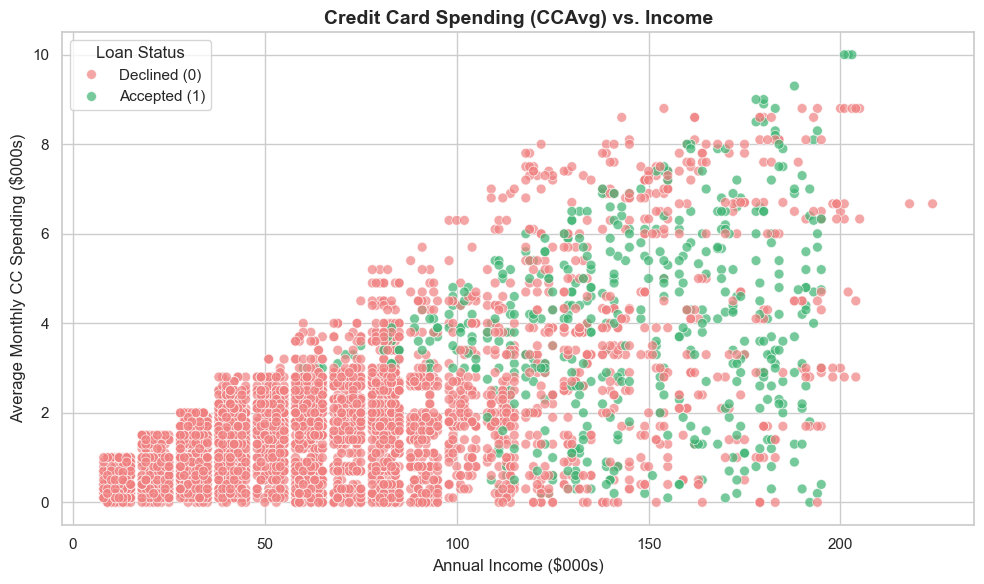

In [124]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Income', 
    y='CCAvg', 
    hue='Loan Status', 
    palette=custom_colors, 
    alpha=0.7,
    s=50 
)
plt.title('Credit Card Spending (CCAvg) vs. Income', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($000s)', fontsize=12)
plt.ylabel('Average Monthly CC Spending ($000s)', fontsize=12)
plt.tight_layout()
plt.show()

Train, Validation, Test Split

In [125]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 3200
Validation set size: 800
Test set size: 1000


In [126]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier 


numeric_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Family']
categorical_features = ['Education']
binary_features = ['Securities Account', 'CD Account', 'Online', 'CreditCard']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        
        ('bin', 'passthrough', binary_features)
    ])

unified_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
unified_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

pipelines

In [127]:
all_models = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42))]),
    'SVM': Pipeline([('preprocessor', preprocessor), ('classifier', SVC(random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))]),
    'Gradient Boosting': Pipeline([('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier(random_state=42))])
}

5-Fold Cross Validation on the Training Set

In [128]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (Training Data)")
print(f"{'Model':<20} | {'Mean F1-Score':<15} | {'Std Dev':<10}")
print("-" * 52)

cv_results = {}

for name, pipeline in all_models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {
        'mean': np.mean(scores),
        'std': np.std(scores)
    }
    print(f"{name:<20} | {np.mean(scores):.4f}          | {np.std(scores):.4f}")

5-Fold Cross-Validation Results (Training Data)
Model                | Mean F1-Score   | Std Dev   
----------------------------------------------------
Logistic Regression  | 0.7316          | 0.0337
Decision Tree        | 0.9013          | 0.0282
SVM                  | 0.8758          | 0.0287
Random Forest        | 0.9123          | 0.0209
Gradient Boosting    | 0.9159          | 0.0314


Hyperparameter Tuning using GridSearchCV

In [129]:
from sklearn.model_selection import GridSearchCV

log_params = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
log_grid = GridSearchCV(all_models['Logistic Regression'], log_params, cv=cv, scoring='f1', n_jobs=-1)
log_grid.fit(X_train, y_train)
print(f"LogReg Best Params: {log_grid.best_params_}")

dt_params = {'classifier__max_depth': [3, 5, 10, 15, None], 'classifier__min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(all_models['Decision Tree'], dt_params, cv=cv, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f"Decision Tree Best Params: {dt_grid.best_params_}")

svm_params = {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf'], 'classifier__gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(all_models['SVM'], svm_params, cv=cv, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f"SVM Best Params: {svm_grid.best_params_}")

rf_params = {'classifier__n_estimators': [50, 100, 150], 'classifier__max_depth': [5, 10, None]}
rf_grid = GridSearchCV(all_models['Random Forest'], rf_params, cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Random Forest Best Params: {rf_grid.best_params_}")

best_rf_model = rf_grid.best_estimator_

LogReg Best Params: {'classifier__C': 100}
Decision Tree Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2}
SVM Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Random Forest Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}


C:\Users\maudt\AppData\Local\Temp\ipykernel_13888\213562679.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_coefficients, y=log_features, palette="coolwarm")


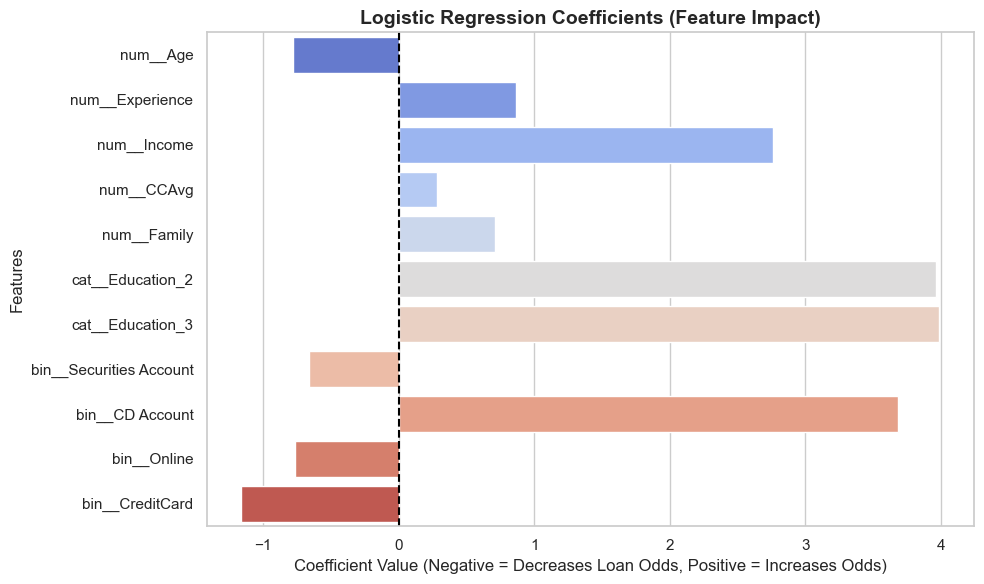

In [139]:
fitted_preprocessor = log_grid.best_estimator_.named_steps['preprocessor']

log_features = fitted_preprocessor.get_feature_names_out()

best_log_model = log_grid.best_estimator_.named_steps['classifier']
log_coefficients = best_log_model.coef_[0]

plt.figure(figsize=(10, 6))
sns.barplot(x=log_coefficients, y=log_features, palette="coolwarm")
plt.title('Logistic Regression Coefficients (Feature Impact)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Negative = Decreases Loan Odds, Positive = Increases Odds)')
plt.ylabel('Features')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

Feature Importance from Random Fores

C:\Users\maudt\AppData\Local\Temp\ipykernel_13888\3227182921.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_names, palette="viridis")


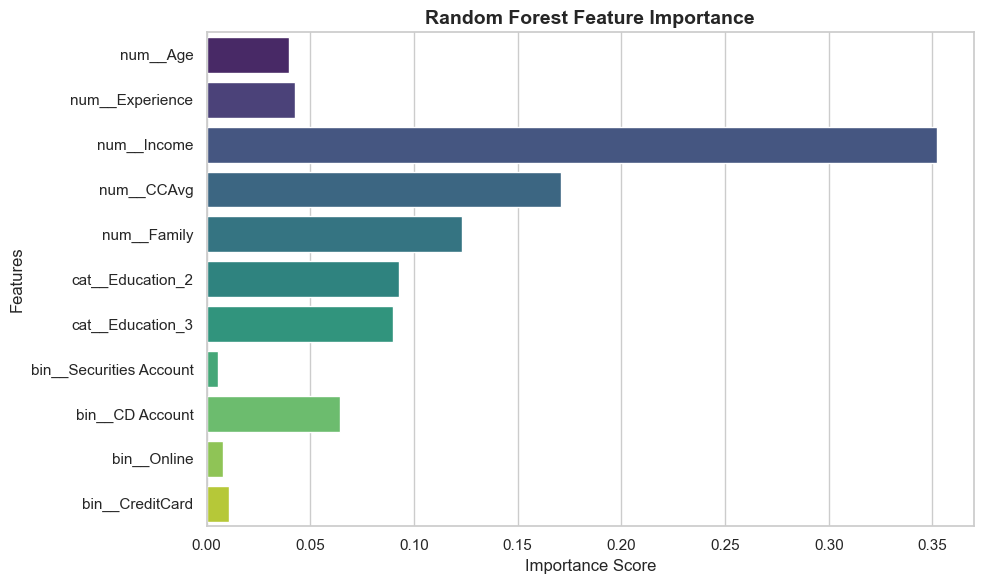

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

fitted_preprocessor = rf_grid.best_estimator_.named_steps['preprocessor']
feature_names = fitted_preprocessor.get_feature_names_out()

best_rf = best_rf_model.named_steps['classifier']
feature_importances = best_rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette="viridis")
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Model Validation Test

In [132]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

best_gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=500,         
        validation_fraction=0.2, 
        n_iter_no_change=10,      
        random_state=42
    ))
])

best_gb_model.fit(X_train, y_train)
best_gb_model

print("Gradient Boosting training complete! 'best_gb_model' is now defined.")

Gradient Boosting training complete! 'best_gb_model' is now defined.


In [133]:
print("Validation Set Performance ")

for name, pipeline in all_models.items():

    pipeline.fit(X_train, y_train)

    y_val_pred = pipeline.predict(X_val)

    val_f1 = f1_score(y_val, y_val_pred)

    print(f"{name:<20} Validation F1: {val_f1:.4f}")

Validation Set Performance 
Logistic Regression  Validation F1: 0.7463
Decision Tree        Validation F1: 0.9189
SVM                  Validation F1: 0.8777
Random Forest        Validation F1: 0.9178
Gradient Boosting    Validation F1: 0.8993


Ultimate Test Set Evaluation  for Unseen Data

In [134]:
print("FINAL TEST SET PERFORMANCE")

y_test_pred_rf = rf_grid.predict(X_test)

print("\nRandom Forest (Baseline) Classification Report:")
print(classification_report(y_test, y_test_pred_rf))


y_test_pred_gb = best_gb_model.predict(X_test)

print("\nGradient Boosting (Tuned) Classification Report:")
print(classification_report(y_test, y_test_pred_gb))

print(f"Tuned GB Final Test Accuracy: {accuracy_score(y_test, y_test_pred_gb):.4f}")
print(f"Tuned GB Final Test F1 (Class 1): {f1_score(y_test, y_test_pred_gb):.4f}")

FINAL TEST SET PERFORMANCE

Random Forest (Baseline) Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       904
           1       0.98      0.95      0.96        96

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000


Gradient Boosting (Tuned) Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       904
           1       0.95      0.96      0.95        96

    accuracy                           0.99      1000
   macro avg       0.97      0.98      0.97      1000
weighted avg       0.99      0.99      0.99      1000

Tuned GB Final Test Accuracy: 0.9910
Tuned GB Final Test F1 (Class 1): 0.9534


Confusion matrices for random forest and gradient boosting

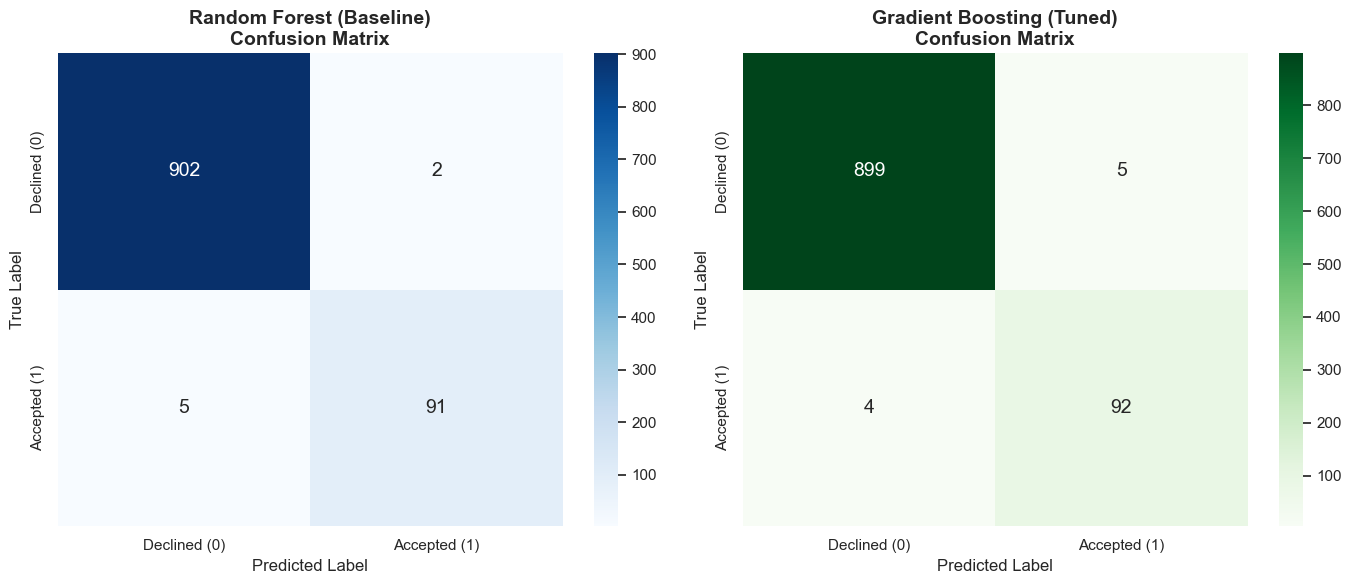

FINAL TEST METRICS: RANDOM FOREST vs GRADIENT BOOSTING

[Random Forest - Baseline]
Test Accuracy: 0.9930
Test F1-Score: 0.9630

Detailed Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       904
           1       0.98      0.95      0.96        96

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000


[Gradient Boosting - Tuned]
Test Accuracy: 0.9910
Test F1-Score: 0.9534

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       904
           1       0.95      0.96      0.95        96

    accuracy                           0.99      1000
   macro avg       0.97      0.98      0.97      1000
weighted avg       0.99      0.99      0.99      1000



In [135]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
cm_gb = confusion_matrix(y_test, y_test_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels = ['Declined (0)', 'Accepted (1)']

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
axes[0].set_title('Random Forest (Baseline)\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
axes[1].set_title('Gradient Boosting (Tuned)\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)


plt.tight_layout()
plt.show()

print("FINAL TEST METRICS: RANDOM FOREST vs GRADIENT BOOSTING")

print(f"\n[Random Forest - Baseline]")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred_rf):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_test_pred_rf))

print(f"\n[Gradient Boosting - Tuned]")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_gb):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred_gb):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_test_pred_gb))

Neural Networks (Custom NN for classification)

In [136]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Testing different Neural Network Configurations...")

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

configs = {
    "Config 1 (Simple)": [Dense(16, activation='relu'), Dense(1, activation='sigmoid')],
    "Config 2 (Medium w/ Dropout)": [Dense(32, activation='relu'), Dropout(0.2), Dense(16, activation='relu'), Dense(1, activation='sigmoid')],
    "Config 3 (Deep w/ Dropout)": [Dense(64, activation='relu'), Dropout(0.2), Dense(32, activation='relu'), Dropout(0.2), Dense(16, activation='relu'), Dense(1, activation='sigmoid')]
}

best_nn_f1 = 0
best_nn_name = ""
best_nn_model = None

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for name, layers in configs.items():
    model = Sequential([tf.keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],))] + layers)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, 
              validation_data=(X_val_scaled, y_val), callbacks=[early_stop], verbose=0)
    
    val_preds = (model.predict(X_val_scaled, verbose=0) > 0.5).astype(int)
    val_f1 = f1_score(y_val, val_preds)
    print(f"{name} -> Validation F1: {val_f1:.4f}")
    
    if val_f1 > best_nn_f1:
        best_nn_f1 = val_f1
        best_nn_name = name
        best_nn_model = model

print(f"\nBest Neural Network: {best_nn_name} with Val F1: {best_nn_f1:.4f}")

Testing different Neural Network Configurations...


c:\Users\maudt\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Config 1 (Simple) -> Validation F1: 0.9116


c:\Users\maudt\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Config 2 (Medium w/ Dropout) -> Validation F1: 0.0000


c:\Users\maudt\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Config 3 (Deep w/ Dropout) -> Validation F1: 0.2093

Best Neural Network: Config 1 (Simple) with Val F1: 0.9116


model evaluation

In [137]:
summary_data = []
preds_log = log_grid.predict(X_test)
summary_data.append({
    'Model Name': 'Logistic Regression',
    'Hyperparameters Tried': "C: [0.01, 0.1, 1, 10, 100]",
    'Best Hyperparameters': str(log_grid.best_params_),
    'Mean CV F1 Score': f"{log_grid.best_score_:.4f}",
    'Std Dev F1 Score': f"{log_grid.cv_results_['std_test_score'][log_grid.best_index_]:.4f}",
    'Test F1 Score': f"{f1_score(y_test, preds_log):.4f}"
})

preds_dt = dt_grid.predict(X_test)
summary_data.append({
    'Model Name': 'Decision Tree',
    'Hyperparameters Tried': "max_depth: [3, 5, 10, 15, None], min_samples_split: [2, 5, 10]",
    'Best Hyperparameters': str(dt_grid.best_params_),
    'Mean CV F1 Score': f"{dt_grid.best_score_:.4f}",
    'Std Dev F1 Score': f"{dt_grid.cv_results_['std_test_score'][dt_grid.best_index_]:.4f}",
    'Test F1 Score': f"{f1_score(y_test, preds_dt):.4f}"
})

preds_svm = svm_grid.predict(X_test)
summary_data.append({
    'Model Name': 'SVM',
    'Hyperparameters Tried': "C: [0.1, 1, 10], kernel: ['linear', 'rbf'], gamma: ['scale', 'auto']",
    'Best Hyperparameters': str(svm_grid.best_params_),
    'Mean CV F1 Score': f"{svm_grid.best_score_:.4f}",
    'Std Dev F1 Score': f"{svm_grid.cv_results_['std_test_score'][svm_grid.best_index_]:.4f}",
    'Test F1 Score': f"{f1_score(y_test, preds_svm):.4f}"
})

preds_rf = rf_grid.predict(X_test)
summary_data.append({
    'Model Name': 'Random Forest',
    'Hyperparameters Tried': "n_estimators: [50, 100, 150], max_depth: [5, 10, None]",
    'Best Hyperparameters': str(rf_grid.best_params_),
    'Mean CV F1 Score': f"{rf_grid.best_score_:.4f}",
    'Std Dev F1 Score': f"{rf_grid.cv_results_['std_test_score'][rf_grid.best_index_]:.4f}",
    'Test F1 Score': f"{f1_score(y_test, preds_rf):.4f}"
})

preds_gb = best_gb_model.predict(X_test)
val_preds_gb = best_gb_model.predict(X_val) 
summary_data.append({
    'Model Name': 'Gradient Boosting',
    'Hyperparameters Tried': "Early Stopping (val_fraction=0.2, patience=10)",
    'Best Hyperparameters': "Early Stopping Reached",
    'Mean CV F1 Score': f"Val F1: {f1_score(y_val, val_preds_gb):.4f}", 
    'Std Dev F1 Score': "N/A", 
    'Test F1 Score': f"{f1_score(y_test, preds_gb):.4f}"
})

preds_nn_probs = best_nn_model.predict(X_test_scaled, verbose=0)
preds_nn = (preds_nn_probs > 0.5).astype(int)
summary_data.append({
    'Model Name': 'Neural Network',
    'Hyperparameters Tried': "Configs: 16->1; 32->Drop->16->1; 64->Drop->32->Drop->16->1",
    'Best Hyperparameters': str(best_nn_name),
    'Mean CV F1 Score': f"Val F1: {best_nn_f1:.4f}",
    'Std Dev F1 Score': 'N/A',
    'Test F1 Score': f"{f1_score(y_test, preds_nn):.4f}"
})

pd.set_option('display.max_colwidth', None)  
pd.set_option('display.width', None)         
metrics_df = pd.DataFrame(summary_data)
display(metrics_df)

,Model Name,Hyperparameters Tried,Best Hyperparameters,Mean CV F1 Score,Std Dev F1 Score,Test F1 Score
0,Logistic Regression,"C: [0.01, 0.1, 1, 10, 100]",{'classifier__C': 100},0.7477,0.0235,0.7674
1,Decision Tree,"max_depth: [3, 5, 10, 15, None], min_samples_split: [2, 5, 10]","{'classifier__max_depth': 10, 'classifier__min_samples_split': 2}",0.9063,0.0310,0.9246
2,SVM,"C: [0.1, 1, 10], kernel: ['linear', 'rbf'], gamma: ['scale', 'auto']","{'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}",0.9082,0.0225,0.9290
3,Random Forest,"n_estimators: [50, 100, 150], max_depth: [5, 10, None]","{'classifier__max_depth': 10, 'classifier__n_estimators': 100}",0.9173,0.0169,0.9630
4,Gradient Boosting,"Early Stopping (val_fraction=0.2, patience=10)",Early Stopping Reached,Val F1: 0.9067,N/A,0.9534
5,Neural Network,Configs: 16->1; 32->Drop->16->1; 64->Drop->32->Drop->16->1,Config 1 (Simple),Val F1: 0.9116,N/A,0.9436
